## Detection of Diabetic Retinopathy using Retinal Images

### Import Essential Dependencies

In [1]:
# import essential dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import models, layers

### Data Loading

In [2]:
# specified the directories of train, test, and validation datasets
train_directory = 'C:\\Users\\65814\\OneDrive\\Projects\\keras_learning\\dataset\\diabetic_retinopathy\\train'
test_directory = 'C:\\Users\\65814\\OneDrive\\Projects\\keras_learning\\dataset\\diabetic_retinopathy\\test'
val_directory = 'C:\\Users\\65814\\OneDrive\\Projects\\keras_learning\\dataset\\diabetic_retinopathy\\valid'

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    rescale = 1./255
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

val_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [4]:
# prepare the train, test, and validation datasets
# apply data augmentation on the train dataset

train_ds = train_datagen.flow_from_directory(
    directory = train_directory,
    target_size = (128,128),
    class_mode = 'binary',
    batch_size = 32,
    shuffle = True,
    seed = 122
)

test_ds = test_datagen.flow_from_directory(
    directory = test_directory,
    target_size = (128,128),
    class_mode = 'binary',
    batch_size = 32,
    seed = 122
)

val_ds = val_datagen.flow_from_directory(
    directory = val_directory,
    target_size = (128,128),
    class_mode = 'binary',
    batch_size = 32,
    seed = 122
)

Found 2076 images belonging to 2 classes.
Found 231 images belonging to 2 classes.
Found 531 images belonging to 2 classes.


### Neural Network from Scratch

#### Model 1

In [5]:
# neural network from scratch
cnn = models.Sequential()

cnn.add(tf.keras.Input(shape=(128,128,3)))
cnn.add(layers.Conv2D(filters=32, kernel_size=(3,3)))
cnn.add(layers.BatchNormalization())
cnn.add(layers.Activation('relu'))
cnn.add(layers.MaxPooling2D(pool_size=(2,2)))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(units=128, activation='relu'))
# cnn.add(layers.Dropout(0.5))
cnn.add(layers.Dense(units=1, activation='sigmoid'))

In [6]:
# compile the model (specified the model learning configuration)
cnn.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [7]:
# fit the neural network with training data
history = cnn.fit(train_ds, epochs=10, validation_data=val_ds)

C:\Users\65814\anaconda3\envs\keras\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 702ms/step - accuracy: 0.5721 - loss: 12.7494 - val_accuracy: 0.8738 - val_loss: 0.6312
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 382ms/step - accuracy: 0.8440 - loss: 0.3921 - val_accuracy: 0.8870 - val_loss: 0.5760
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 376ms/step - accuracy: 0.8633 - loss: 0.3536 - val_accuracy: 0.8230 - val_loss: 0.5086
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 26s 393ms/step - accuracy: 0.8701 - loss: 0.3376 - val_accuracy: 0.8870 - val_loss: 0.4432
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 390ms/step - accuracy: 0.8891 - loss: 0.2979 - val_accuracy: 0.8663 - val_loss: 0.4031
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 391ms/step - accuracy: 0.8727 - loss: 0.3308 - val_accuracy: 0.8889 - val_loss: 0.3470
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 26s 395ms/step - accuracy: 0.8888 - loss: 0.2884 - val_accuracy: 0.9134 - val_loss: 0.3129
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 386ms/step - accuracy: 0.8712 - loss: 0.3159 - val_acc

In [8]:
# evaluate the model accuracy on test dataset
res_cnn = cnn.evaluate(test_ds)
print('Model Accuracy on Test Dataset:', round(res_cnn[1]*100),'%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 0.8945 - loss: 0.2338
Model Accuracy on Test Dataset: 90 %


In [9]:
# define a function to plot the accuracy and loss curve
def plot_curves(train_acc, val_acc, train_loss, val_loss):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend(loc='upper left')
    plt.title('Model Accuracy')

    plt.subplot(1,2,2)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend(loc='upper left')
    plt.title('Model Loss')

    plt.show()

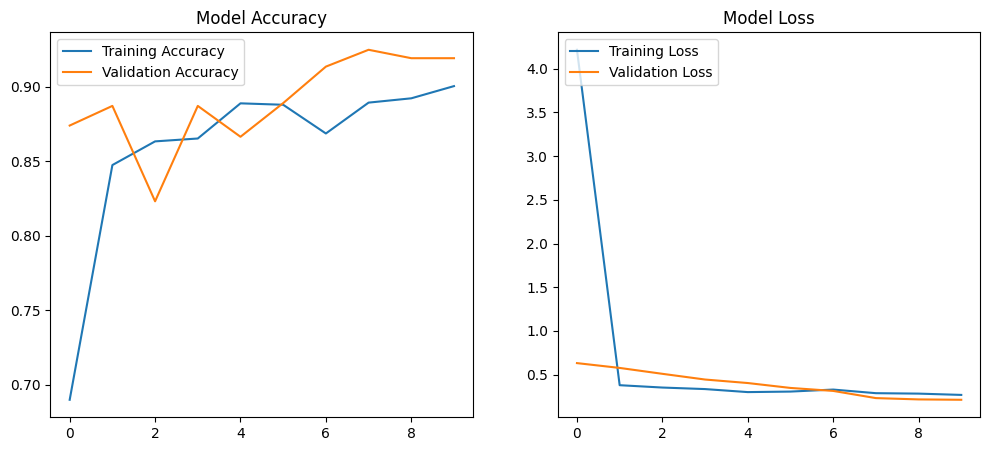

In [10]:
# visualize the model accuracy and loss
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

plot_curves(train_acc, val_acc, train_loss, val_loss)

#### Model 2: Deeper CNN Network

In [11]:
# neural network from scratch
cnn_deeper = models.Sequential()

cnn_deeper.add(tf.keras.Input(shape=(128,128,3)))
cnn_deeper.add(layers.Conv2D(filters=32, kernel_size=(3,3)))
cnn_deeper.add(layers.BatchNormalization())
cnn_deeper.add(layers.Activation('relu'))
cnn_deeper.add(layers.MaxPooling2D(pool_size=(2,2)))

cnn_deeper.add(layers.Conv2D(filters=64, kernel_size=(3,3)))
cnn_deeper.add(layers.BatchNormalization())
cnn_deeper.add(layers.Activation('relu'))
cnn_deeper.add(layers.MaxPooling2D(pool_size=(2,2)))

cnn_deeper.add(layers.Conv2D(filters=128, kernel_size=(3,3)))
cnn_deeper.add(layers.BatchNormalization())
cnn_deeper.add(layers.Activation('relu'))
cnn_deeper.add(layers.MaxPooling2D(pool_size=(2,2)))

cnn_deeper.add(layers.Flatten())

cnn_deeper.add(layers.Dense(units=128, activation='relu'))
cnn_deeper.add(layers.Dense(units=1, activation='sigmoid'))

In [12]:
# compile the model (specified the model learning configuration)
cnn_deeper.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [13]:
# fit the neural network with training dataset
history_cnn_deeper = cnn_deeper.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 496ms/step - accuracy: 0.6249 - loss: 3.4154 - val_accuracy: 0.4614 - val_loss: 1.0470
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 485ms/step - accuracy: 0.8381 - loss: 0.3575 - val_accuracy: 0.4614 - val_loss: 1.5626
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 491ms/step - accuracy: 0.8682 - loss: 0.3072 - val_accuracy: 0.4614 - val_loss: 2.2657
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 487ms/step - accuracy: 0.8898 - loss: 0.2894 - val_accuracy: 0.4614 - val_loss: 2.0433
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 489ms/step - accuracy: 0.8948 - loss: 0.2663 - val_accuracy: 0.4614 - val_loss: 1.9832
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 31s 480ms/step - accuracy: 0.9012 - loss: 0.2548 - val_accuracy: 0.4878 - val_loss: 1.1639
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 31s 477ms/step - accuracy: 0.8968 - loss: 0.2482 - val_accuracy: 0.4878 - val_loss: 1.1498
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 31s 482ms/step - accuracy: 0.9094 - loss: 0.2359 - val_accu

In [14]:
# eveluate the model accuracy on test dataset
res_cnn_deeper = cnn_deeper.evaluate(test_ds)
print('Model Accuracy on Test Dataset:', round(res_cnn_deeper[1]*100),'%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8995 - loss: 0.2928
Model Accuracy on Test Dataset: 91 %


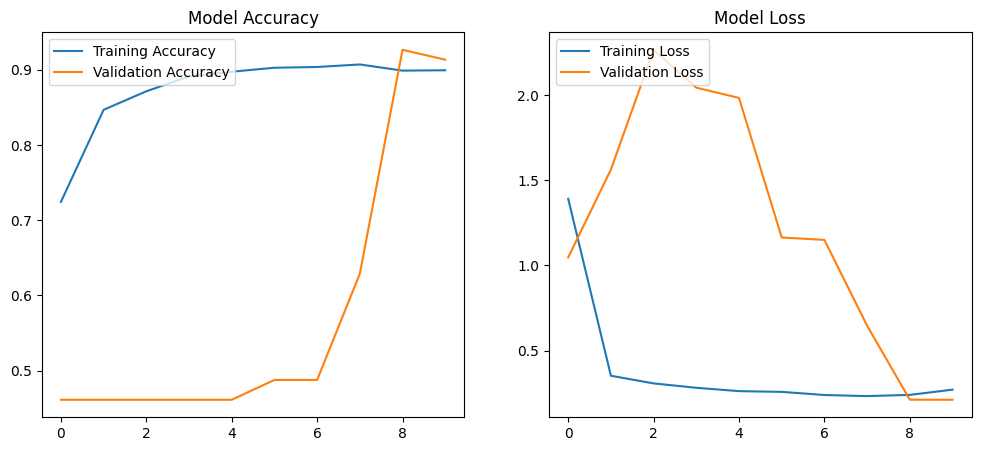

In [15]:
# visualize the model accuracy and loss
cnn_deeper_train_acc = history_cnn_deeper.history['accuracy']
cnn_deeper_train_loss = history_cnn_deeper.history['loss']
cnn_deeper_val_acc = history_cnn_deeper.history['val_accuracy']
cnn_deeper_val_loss = history_cnn_deeper.history['val_loss']

plot_curves(cnn_deeper_train_acc, cnn_deeper_val_acc, cnn_deeper_train_loss, cnn_deeper_val_loss)

### Transfer Learning

#### Pre-trained Model: ResNet50

In [16]:
# pre-trained ResNet50 model
base_resnet = keras.applications.ResNet50(
    include_top = False,
    weights = 'imagenet',
    input_shape = (128,128,3)
)

In [17]:
# freeze the layers of the pre-trained model
base_resnet.trainable = False

In [18]:
# build a Resnet network on top of the base model
resnet = models.Sequential()

resnet.add(base_resnet)
resnet.add(layers.Flatten())
resnet.add(layers.Dense(units=128, activation='relu'))
resnet.add(layers.Dense(units=1, activation='sigmoid'))

In [19]:
# compile the model (configure the learning process)\
resnet.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [20]:
# fit the neural network with training dataset
history_resnet = resnet.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 59s 815ms/step - accuracy: 0.5244 - loss: 0.8111 - val_accuracy: 0.8663 - val_loss: 0.5406
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 765ms/step - accuracy: 0.7157 - loss: 0.6125 - val_accuracy: 0.7928 - val_loss: 0.4437
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 774ms/step - accuracy: 0.6802 - loss: 0.5692 - val_accuracy: 0.8870 - val_loss: 0.3421
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 49s 755ms/step - accuracy: 0.7757 - loss: 0.5004 - val_accuracy: 0.8776 - val_loss: 0.3044
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 49s 750ms/step - accuracy: 0.7760 - loss: 0.4737 - val_accuracy: 0.8738 - val_loss: 0.3000
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 768ms/step - accuracy: 0.8016 - loss: 0.4477 - val_accuracy: 0.8851 - val_loss: 0.2768
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 768ms/step - accuracy: 0.8076 - loss: 0.4226 - val_accuracy: 0.8870 - val_loss: 0.2615
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 51s 789ms/step - accuracy: 0.7979 - loss: 0.4350 - val_accu

In [21]:
# evaluate the model accuracy on test dataset
res_resnet = resnet.evaluate(test_ds)
print('Model Accuracy on Test Dataset:', round(res_resnet[1]*100),'%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step - accuracy: 0.8713 - loss: 0.3237
Model Accuracy on Test Dataset: 87 %


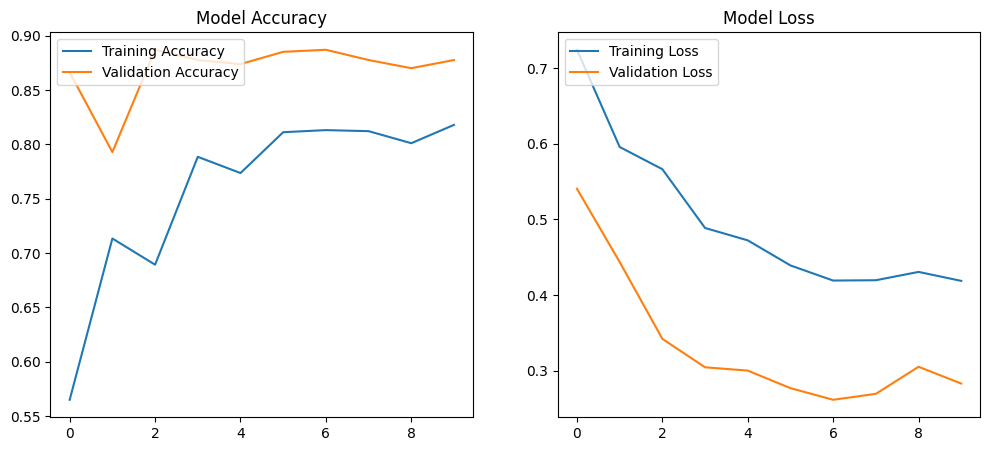

In [22]:
# visualize the model accuracy and loss
resnet_train_acc = history_resnet.history['accuracy']
resnet_train_loss = history_resnet.history['loss']
resnet_val_acc = history_resnet.history['val_accuracy']
resnet_val_loss = history_resnet.history['val_loss']

plot_curves(resnet_train_acc, resnet_val_acc, resnet_train_loss, resnet_val_loss)

#### Pre-trained Model: VGG16

In [23]:
# load the pre-trained model VGG16
base_vgg = keras.applications.VGG16(
    include_top = False,
    weights = 'imagenet',
    input_shape = (128,128,3)
)

In [24]:
# freeze the layers of the pre=trained model
base_vgg.trainable = False

In [25]:
# build a Resnet network on top of the base model
vgg16 = models.Sequential()

vgg16.add(base_vgg)
vgg16.add(layers.Flatten())
vgg16.add(layers.Dense(units=128, activation='relu'))
vgg16.add(layers.Dense(units=1, activation='sigmoid'))

In [26]:
# compile the model (configure the learning process)\
vgg16.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [27]:
# fit the neural network with the test dataset
history_vgg = vgg16.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.7632 - loss: 0.6147 - val_accuracy: 0.9171 - val_loss: 0.2531
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9004 - loss: 0.2768 - val_accuracy: 0.9228 - val_loss: 0.2016
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9180 - loss: 0.2257 - val_accuracy: 0.9209 - val_loss: 0.1881
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9041 - loss: 0.2433 - val_accuracy: 0.9247 - val_loss: 0.1948
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9316 - loss: 0.2083 - val_accuracy: 0.9266 - val_loss: 0.2151
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9366 - loss: 0.1904 - val_accuracy: 0.9266 - val_loss: 0.1789
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9349 - loss: 0.1911 - val_accuracy: 0.9247 - val_loss: 0.2047
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9404 - loss: 0.1674 - val_accuracy: 0.9322 - v

In [29]:
# evaluate the model accuracy on test dataset
res_vgg = vgg16.evaluate(test_ds)
print('Model Accuracy on Test Dataset:', round(res_vgg[1]*100),'%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9204 - loss: 0.2225
Model Accuracy on Test Dataset: 93 %


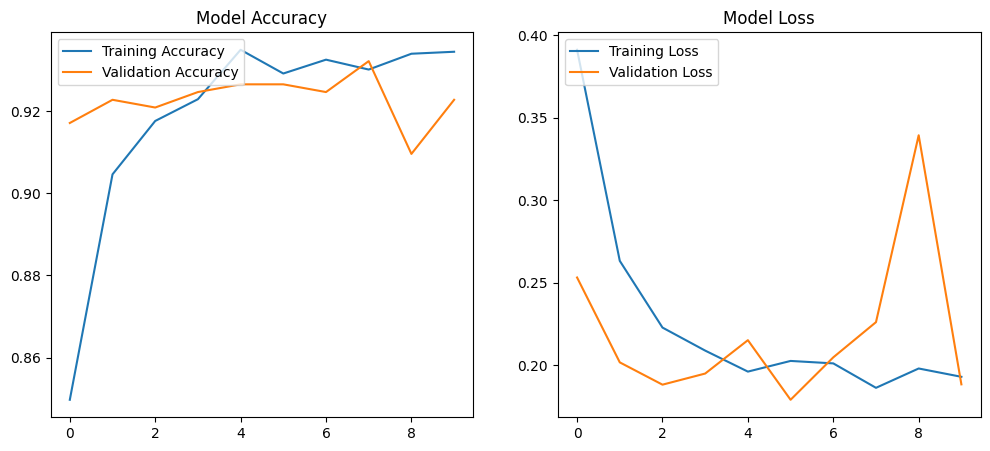

In [30]:
# visualize the model accuracy and loss
vgg_train_acc = history_vgg.history['accuracy']
vgg_train_loss = history_vgg.history['loss']
vgg_val_acc = history_vgg.history['val_accuracy']
vgg_val_loss = history_vgg.history['val_loss']

plot_curves(vgg_train_acc, vgg_val_acc, vgg_train_loss, vgg_val_loss)

### Model Performance

In [31]:
# define a helper function to convert the dataset in numpy format
def data_in_numpy(directory):
    # load dataset in batches
    dataset = keras.utils.image_dataset_from_directory(
        directory=directory,
        batch_size=32,
        image_size=(128, 128),
        shuffle=False
    )
    
    # containers to store images and labels
    img_cont = []
    label_cont = []
    
    for batch in dataset:
        images, labels = batch
        img_cont.append(images.numpy().astype('uint8'))
        label_cont.append(labels.numpy())
    
    # concatenate batches to form the complete dataset
    return np.concatenate(img_cont), np.concatenate(label_cont)

In [32]:
training_data, training_label = data_in_numpy(train_directory)
test_data, test_label = data_in_numpy(test_directory)
val_data, val_label = data_in_numpy(val_directory)

Found 2076 files belonging to 2 classes.
Found 231 files belonging to 2 classes.
Found 531 files belonging to 2 classes.


In [33]:
# predict the class 
pred_proba = vgg16.predict(test_data/255.)
ypred = (pred_proba > 0.5).astype(int)

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


In [34]:
# classification report
from sklearn.metrics import classification_report

report = classification_report(test_label, ypred)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.88      0.92       113
           1       0.90      0.97      0.93       118

    accuracy                           0.93       231
   macro avg       0.93      0.93      0.93       231
weighted avg       0.93      0.93      0.93       231



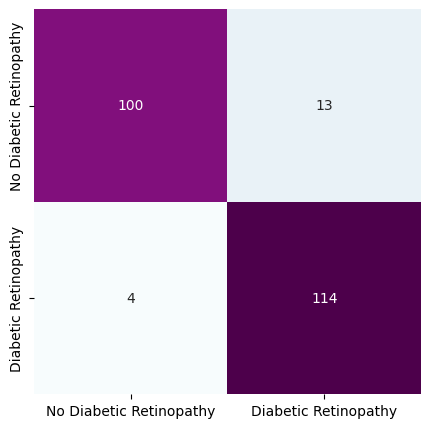

In [35]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_label, ypred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='.4g', cmap='BuPu', cbar=False, xticklabels=['No Diabetic Retinopathy','Diabetic Retinopathy'], yticklabels=['No Diabetic Retinopathy','Diabetic Retinopathy'])
plt.show()

In [36]:
# get the list of the images incorrectly classify by the model
df = pd.DataFrame([test_label, ypred.reshape(-1,)]).T
df.columns = ['Actual', 'Predicted']

wrong_prediction = []
for index, row in df.iterrows():
    if row['Actual'] != row['Predicted']:
        wrong_prediction.append(index)

wrong_prediction

[5, 23, 38, 48, 51, 57, 73, 78, 88, 95, 98, 105, 108, 156, 159, 164, 187]

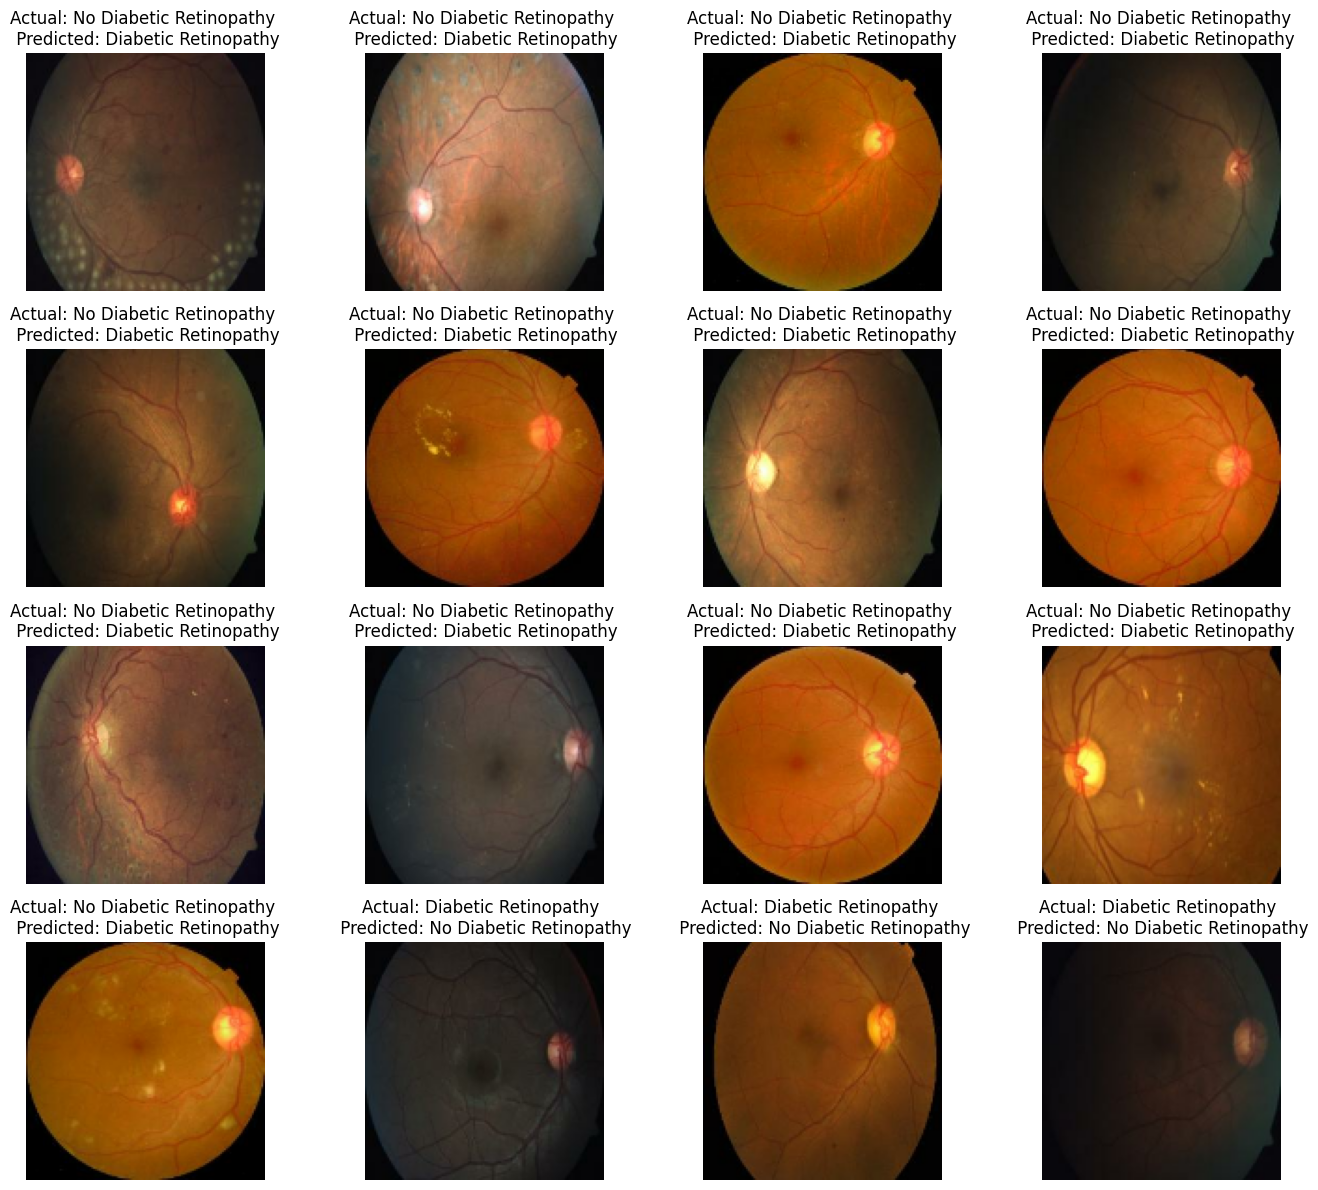

In [39]:
# check the wrong predictions in test dataset
class_label = ['No Diabetic Retinopathy','Diabetic Retinopathy']

fig, axs = plt.subplots(4,4, figsize=(15,12))
for index, axs_index in zip(wrong_prediction, np.ndindex(axs.shape)):
    axs[axs_index].imshow(test_data[index])
    axs[axs_index].set_title('Actual: {} \n Predicted: {}'.format(class_label[test_label[index]], class_label[ypred.reshape(-1,)[index]]))
    axs[axs_index].axis('off')
    plt.tight_layout()